In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/adult11.csv')

for column in df.columns:
    unique_vals = df[column].unique().tolist()
    print(f"Столбец '{column}': {unique_vals}")
    
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'salary']

## Блок 1

Предобработка: очистка данных от выбросов и пустых значений (1 очко)

In [6]:
from sklearn.impute import SimpleImputer

df = df.replace('', np.nan)
df = df.replace('?', np.nan)
df_clean = df.copy()

imputer = SimpleImputer(strategy='most_frequent')
df_clean['workclass'] = pd.Series(imputer.fit_transform(df[['workclass']]).ravel())
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Оригинальный размер: {len(df)} строк")
print(f"Очищенный размер: {len(df_clean)} строк")

Оригинальный размер: 48842 строк
Очищенный размер: 48842 строк


## Блок 2

Провести  осознанное  преобразование  признаков:  изменение  шкалы, преобразование к числовым значениям (2 очка);

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df_transformed = df_clean.copy()

for col in numeric_features:
    df_transformed[col] = pd.to_numeric(df_transformed[col], errors='coerce')

means = df_transformed[numeric_features].mean(axis=0)
stds = df_transformed[numeric_features].std(axis=0)
df_transformed[numeric_features] = (df_transformed[numeric_features] - means) / stds

print("Векторизованная нормализация:")
print("Средние:", df_transformed[numeric_features].mean().round(6).tolist())
print("Стд отклонения:", df_transformed[numeric_features].std().round(6).tolist())

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_transformed[col] = le.fit_transform(df_transformed[col].astype(str))
    label_encoders[col] = le

print("\nПосле стандартизации (M=0, D=1):")
print(df_transformed[numeric_features].round(3))


Векторизованная нормализация:
Средние: [0.0, -0.0, -0.0, 0.0, -0.0, 0.0]
Стд отклонения: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

После стандартизации (M=0, D=1):
         age  fnlwgt  education-num  capital-gain  capital-loss  \
0     -0.995   0.352         -1.197        -0.145        -0.217   
1     -0.047  -0.946         -0.419        -0.145        -0.217   
2     -0.776   1.395          0.748        -0.145        -0.217   
3      0.391  -0.278         -0.030         0.887        -0.217   
4     -1.506  -0.816         -0.030        -0.145        -0.217   
...      ...     ...            ...           ...           ...   
48837 -0.849   0.640          0.748        -0.145        -0.217   
48838  0.099  -0.334         -0.419        -0.145        -0.217   
48839  1.412  -0.358         -0.419        -0.145        -0.217   
48840 -1.214   0.112         -0.419        -0.145        -0.217   
48841  0.974   0.930         -0.419         1.871        -0.217   

       hours-per-week  
0              -0

## Блок 2

Отобразить данные с использованием методов PCA, MDS, t-SNE или UMAP или аналогичных (3 очка)

PCA объясненная дисперсия: 0.668


c:\Work\Repos\nns-labs\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_25624\2719381140.py:42: UserWarning: Adding colorbar to a different Figure <Figure size 2500x2000 with 5 Axes> than <Figure size 1800x500 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, ax=axes[0,0], label='>50K')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_25624\2719381140.py:62: UserWarning: Adding colorbar to a different Figure <Figure size 2500x2000 with 6 Axes> than <Figure size 1800x500 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, ax=axes[0,1], label='>50K')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_25624\2719381140.py:70: UserWarning: Adding colorbar to a different Figure <Figure size 2500x2000 with 7 Axes> than <Figure size 1800x500 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, ax=axes[1,0], labe

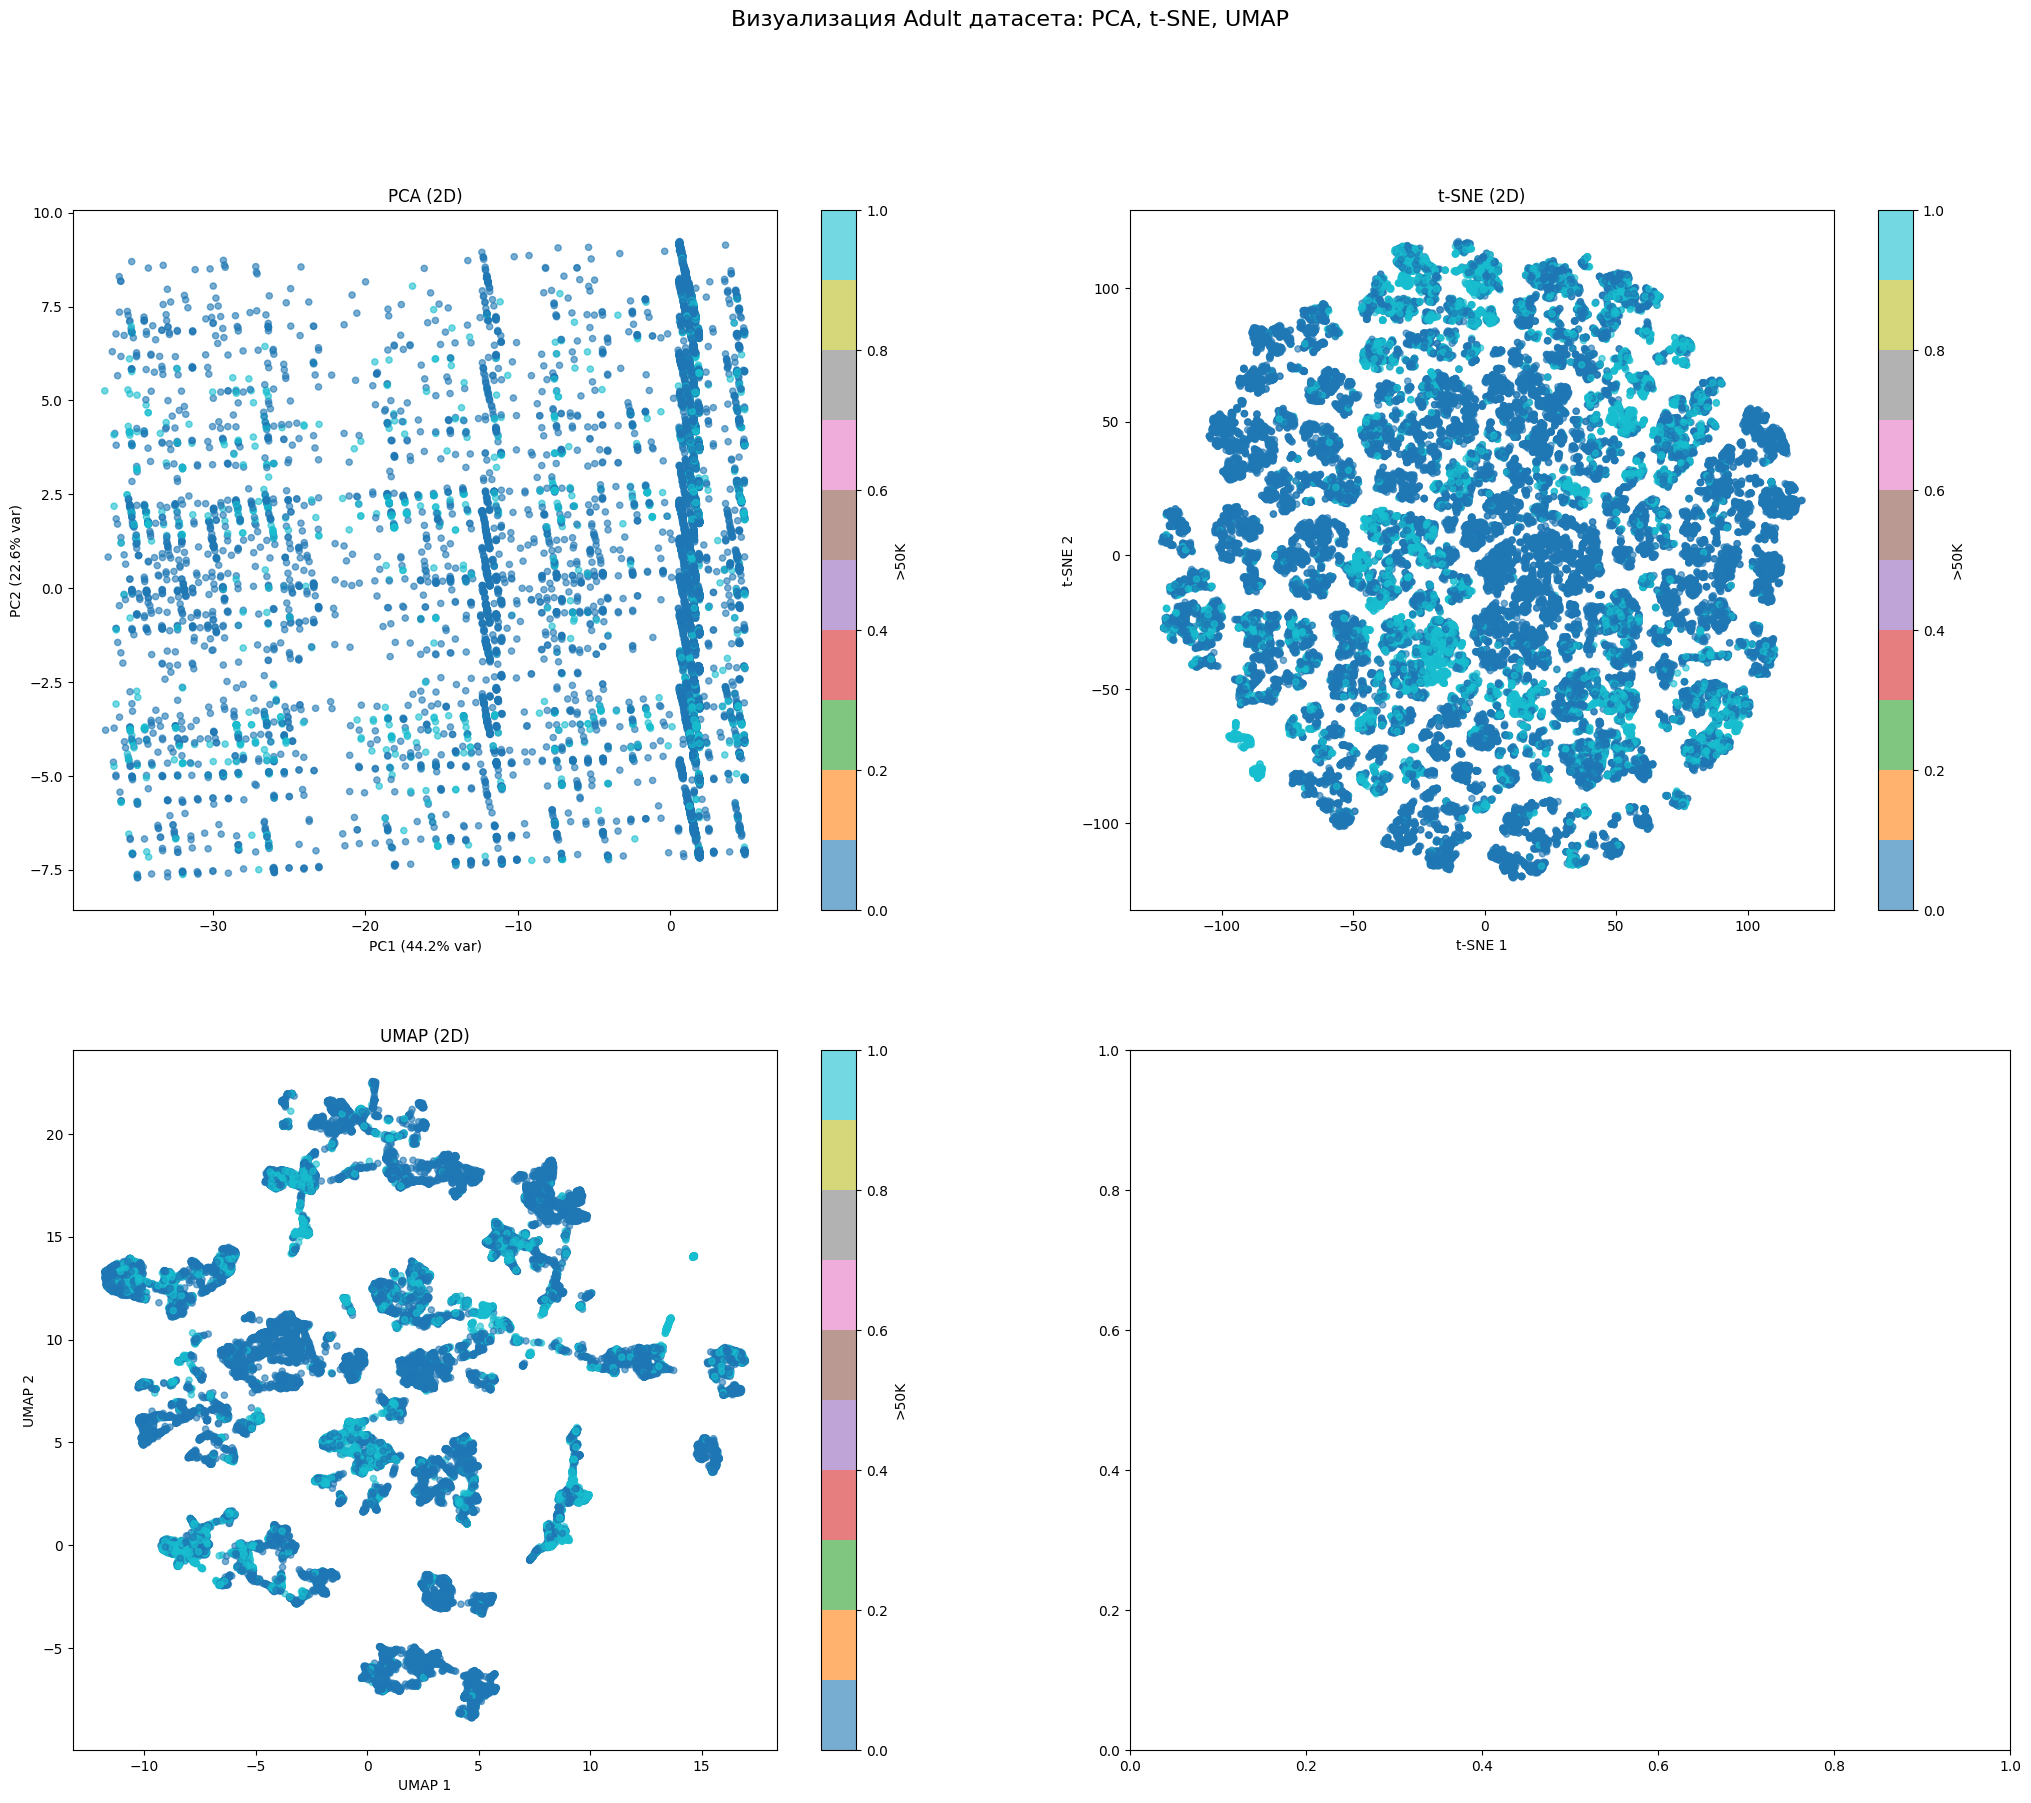

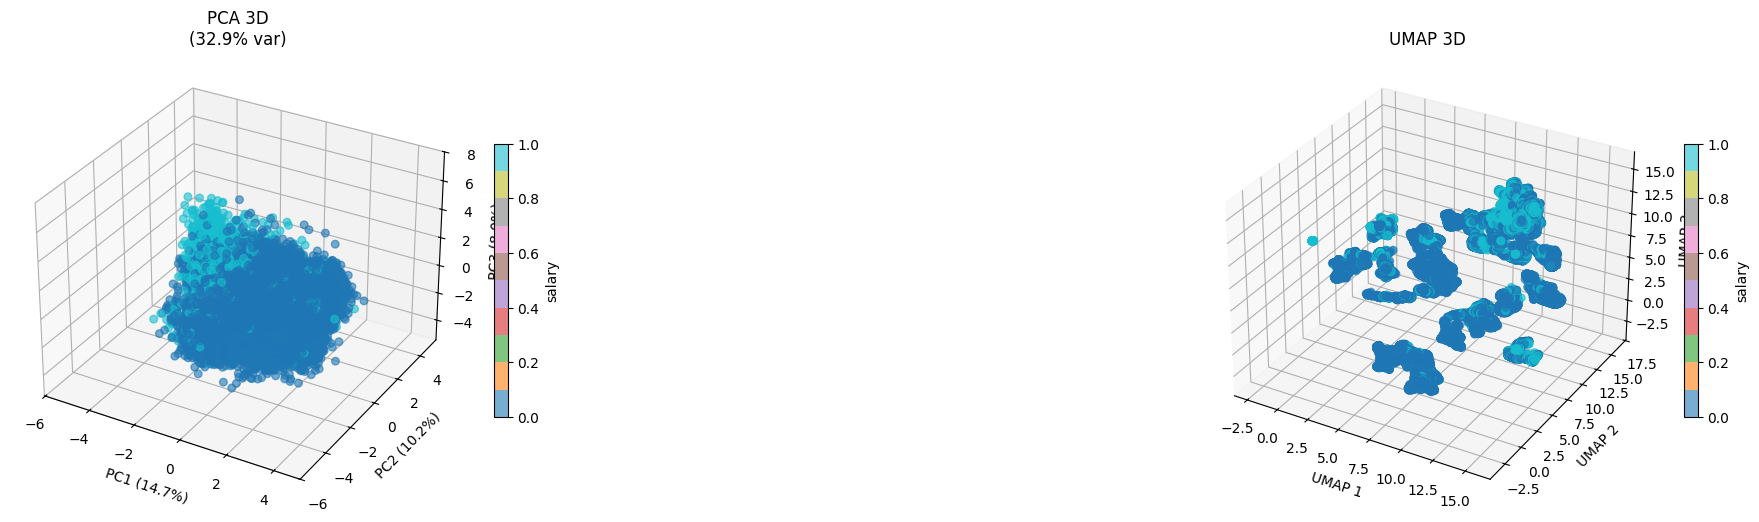

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_transformed['salary'].replace(0, -1)
X = df_transformed.drop('salary', axis=1)
y = df_transformed['salary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"PCA объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

# t-SNE (2D)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# UMAP (2D)
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_model.fit_transform(X)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(25, 20))
fig3d = plt.figure(figsize=(18, 5))
fig.suptitle('Визуализация Adult датасета: PCA, t-SNE, UMAP', fontsize=16)

# PCA
scatter = axes[0,0].scatter(X_pca[:,0], X_pca[:,1], c=y, 
                           cmap='tab10', alpha=0.6, s=20)
axes[0,0].set_title('PCA (2D)')
axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(scatter, ax=axes[0,0], label='>50K')

# PCA 3D
ax1 = fig3d.add_subplot(131, projection='3d')
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)
scatter = ax1.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], 
                      c=y, cmap='tab10', alpha=0.6, s=30)
ax1.set_title(f'PCA 3D\n({pca_3d.explained_variance_ratio_.sum():.1%} var)')
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
plt.colorbar(scatter, ax=ax1, shrink=0.6, label='salary')

# t-SNE
scatter = axes[0,1].scatter(X_tsne[:,0], X_tsne[:,1], c=y, 
                           cmap='tab10', alpha=0.6, s=20)
axes[0,1].set_title('t-SNE (2D)')
axes[0,1].set_xlabel('t-SNE 1')
axes[0,1].set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=axes[0,1], label='>50K')

# UMAP
scatter = axes[1,0].scatter(X_umap[:,0], X_umap[:,1], c=y, 
                           cmap='tab10', alpha=0.6, s=20)
axes[1,0].set_title('UMAP (2D)')
axes[1,0].set_xlabel('UMAP 1')
axes[1,0].set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=axes[1,0], label='>50K')

# UMAP 3D
ax2 = fig3d.add_subplot(133, projection='3d')
umap_3d = umap.UMAP(n_components=3, random_state=42, n_neighbors=15)
X_umap_3d = umap_3d.fit_transform(X_scaled)
scatter = ax2.scatter(X_umap_3d[:,0], X_umap_3d[:,1], X_umap_3d[:,2], 
                      c=y, cmap='tab10', alpha=0.6, s=30)
ax2.set_title('UMAP 3D')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_zlabel('UMAP 3')
plt.colorbar(scatter, ax=ax2, shrink=0.6, label='salary')

plt.tight_layout()
plt.show()

## Блок 3

Провести сравнение данных до и после преобразования признаков (2 очка)


1. Базовые статистики по числовым параметрам:
               age      fnlwgt  education-num  capital-gain  capital-loss  \
До_mean     38.644  189664.135         10.078      1079.068        87.502   
До_std      13.711  105604.025          2.571      7452.019       403.005   
После_mean   0.000      -0.000         -0.000         0.000        -0.000   
После_std    1.000       1.000          1.000         1.000         1.000   

            hours-per-week  
До_mean             40.422  
До_std              12.391  
После_mean           0.000  
После_std            1.000  

2. Евклидовы расстояния (нормализация должна уменьшить разброс):
До:  113086.908
После:2.991
Изменение: 0.000x


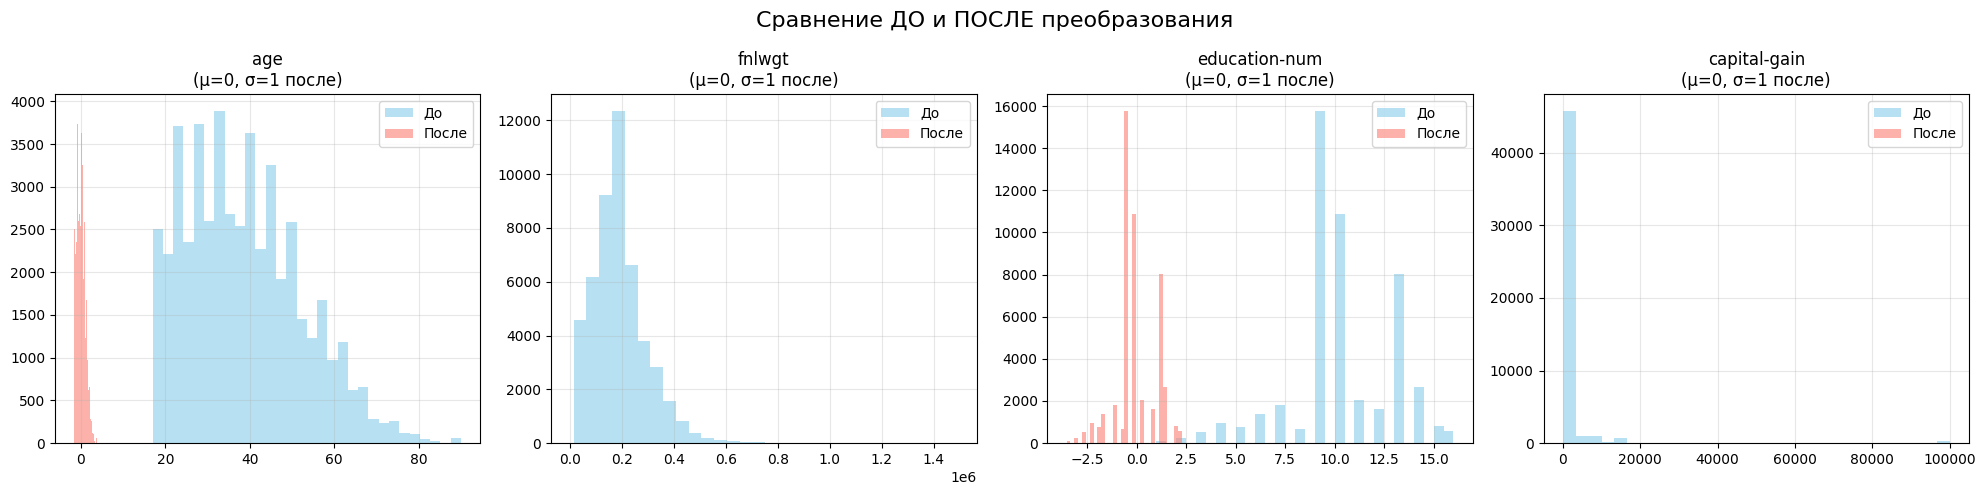

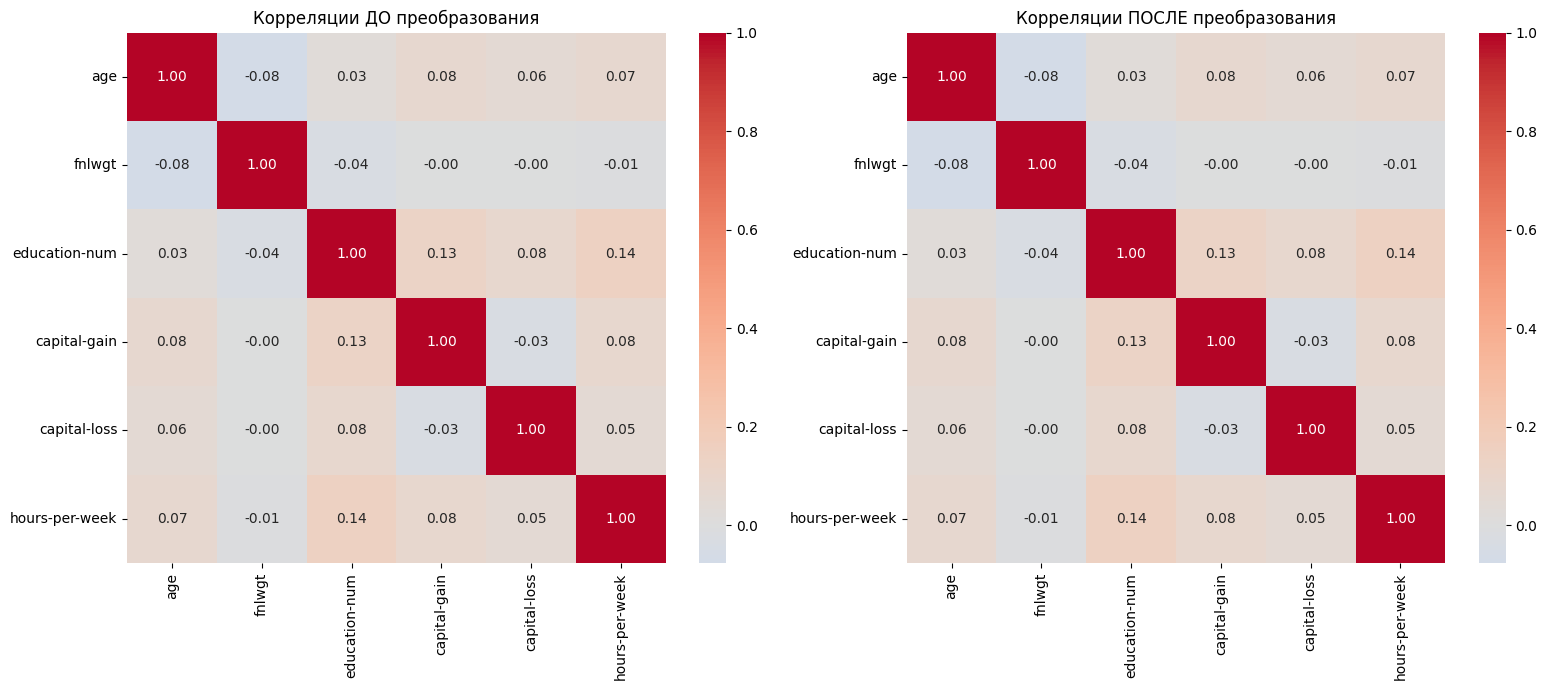

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, shapiro
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_before = df_clean.copy()

print("\n1. Базовые статистики по числовым параметрам:")

stats_before = df_before[numeric_features].describe()
stats_after = df_transformed[numeric_features].describe()

comparison_stats = pd.DataFrame({
    'До_mean': stats_before.loc['mean'],
    'До_std': stats_before.loc['std'], 
    'После_mean': stats_after.loc['mean'],
    'После_std': stats_after.loc['std']
}).round(3)

print(comparison_stats.T)

print("\n2. Евклидовы расстояния (нормализация должна уменьшить разброс):")
dist_before = np.mean(euclidean_distances(df_before[numeric_features].values))
dist_after = np.mean(euclidean_distances(df_transformed[numeric_features].values))
print(f"До:  {dist_before:.3f}")
print(f"После:{dist_after:.3f}")
print(f"Изменение: {dist_after/dist_before:.3f}x")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Сравнение ДО и ПОСЛЕ преобразования', fontsize=16)
sample_features = numeric_features[:4]
for i, col in enumerate(sample_features):
    ax = axes[i]
    ax.hist(df_before[col].dropna(), alpha=0.6, label='До', bins=30, color='skyblue')
    ax.hist(df_transformed[col].dropna(), alpha=0.6, label='После', bins=30, color='salmon')
    ax.set_title(f'{col}\n(μ=0, σ=1 после)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
numeric_sample = numeric_features[:10]

sns.heatmap(df_before[numeric_sample].corr(), annot=True, cmap='coolwarm', ax=ax1,
            center=0, fmt='.2f')
ax1.set_title('Корреляции ДО преобразования')

sns.heatmap(df_transformed[numeric_sample].corr(), annot=True, cmap='coolwarm', ax=ax2,
            center=0, fmt='.2f')
ax2.set_title('Корреляции ПОСЛЕ преобразования')

plt.tight_layout()
plt.savefig('correlation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Блок 4

Отобразить максимальный объем данных без использования методов снижения размерности пространства (2 очка)

Pairplot всех пар признаков...


<Figure size 1600x1200 with 0 Axes>

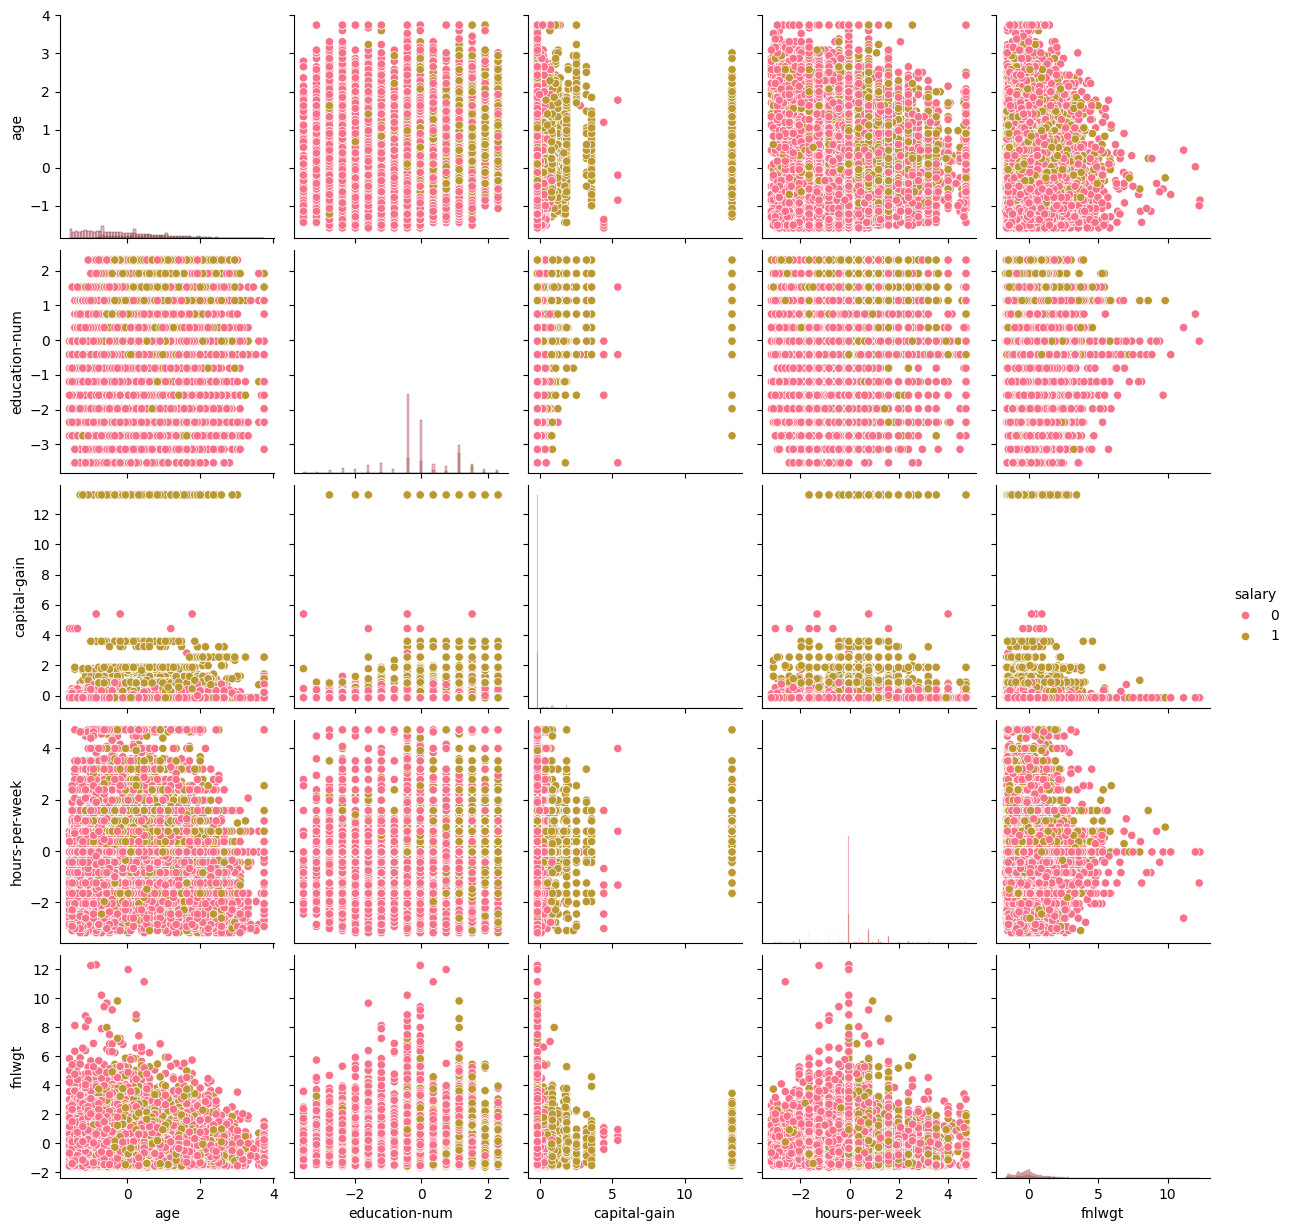


Heatmap корреляций...


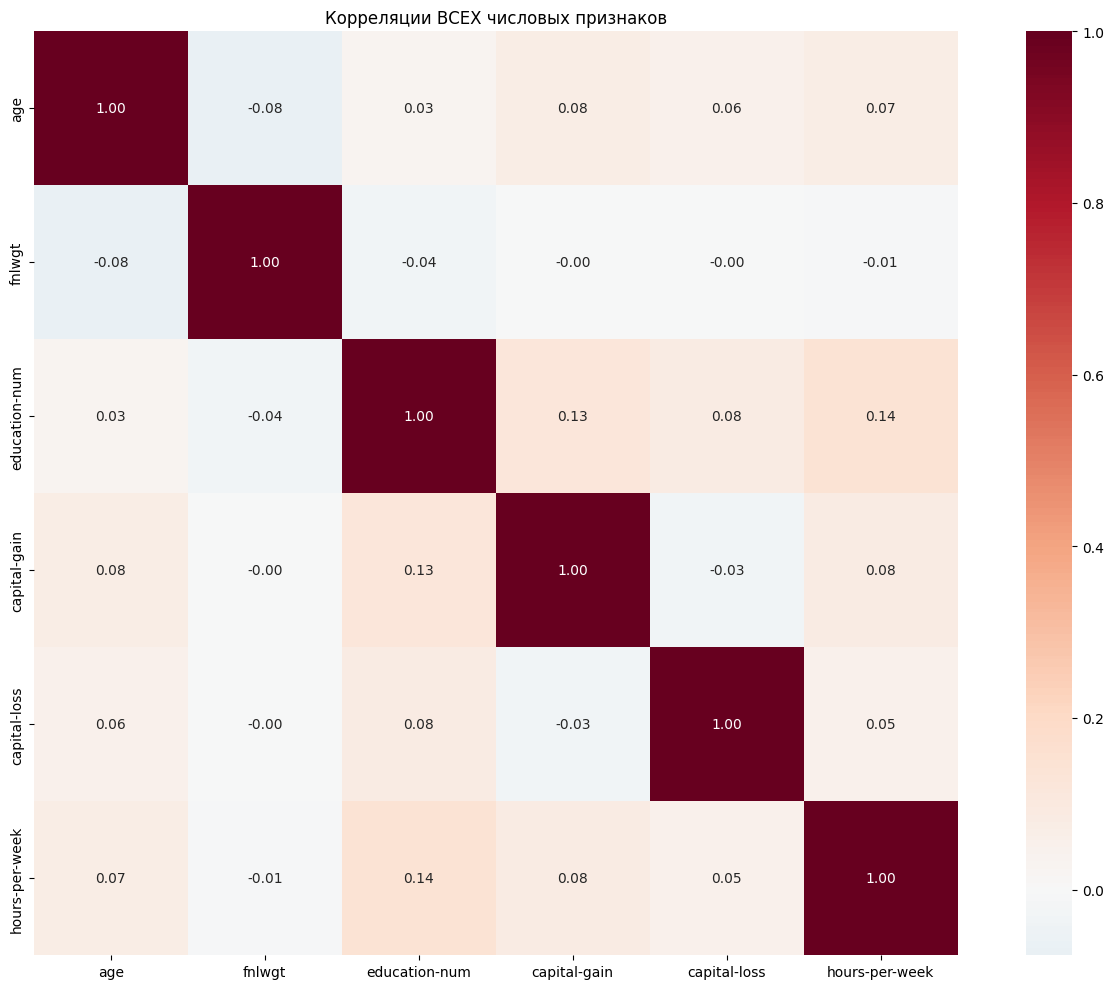

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pandas.plotting import parallel_coordinates
plt.style.use('default')
sns.set_palette("husl")

print("Pairplot всех пар признаков...")
plt.figure(figsize=(16, 12))

sns.pairplot(df_transformed[['salary', 'age', 'education-num', 'capital-gain', 
                            'hours-per-week', 'fnlwgt']], 
             hue='salary', diag_kind='hist')
plt.show()

print("\nHeatmap корреляций...")
plt.figure(figsize=(14, 10))
numeric_cols = df_transformed[numeric_features].columns
corr_matrix = df_transformed[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f')
plt.title('Корреляции ВСЕХ числовых признаков')
plt.tight_layout()
plt.show()
